## 0. Constants/Imports

In [121]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
WIENER_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/unfolding'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
sys.path.insert(0,WIENER_DIR)
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

#My imports
from sbnd.cafclasses.slice import CAFSlice
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import * # >= v2.2
from sbnd.general import plotters
from sbnd.general.utils import convert_pnfs_to_xroot,h5py_file_xrootd,read_hdf_xrootd
from naming import *
from sbnd.stats.systematics import Systematics

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [122]:
from datetime import date
day = date.today().strftime("%Y_%m_%d")

BASE_DIR = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
PNFS_BASE_DIR = '/pnfs/sbnd/persistent/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
PLOT_DIR = f'{BASE_DIR}/plots/{day}/syst'
TABLE_DIR = f'{BASE_DIR}/tables/{day}/syst'
VERSION = 'v5'

MC_FNAME = f'{BASE_DIR}/mc_syst/v6/mc_smallpand_fullsyst_cut_norecomb.df'
MC_LOWE_FNAME = f'{BASE_DIR}/mc_lowe/{VERSION}/mc_smallpand_fullsyst_cut_norecomb3.df'

# MC_FNAME = f'{BASE_DIR}/mc_syst/{VERSION}/mc_medpand_nosyst_nocuts_recomb3.df'
# MC_LOWE_FNAME = f'{BASE_DIR}/mc_lowe/{VERSION}/mc_medpand_slimsyst_nocuts_norecomb3.df'

OFFBEAM_FNAME = f'{BASE_DIR}/offbeam/{VERSION}/mc_smallpand_nosyst_nocuts_recomb3.df'
DATA_FNAME = f'{BASE_DIR}/data/{VERSION}/dataonbeam_nocuts3.df'

FLUX_FILE = '/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root'

In [123]:
day

'2026_03_10'

## 1. Load data

In [124]:
# Get keys for h5 files
import h5py
mcnu_keys = []
mcnu_lowe_keys = []


#Slices - signal
mc_signal_pand_keys = []
mc_signal_lowe_pand_keys = []

#Slices - selected
mc_selected_pand_keys = []
mc_selected_lowe_pand_keys = []

# Slices (no cuts)
mc_pand_keys = []
mc_lowe_pand_keys = []

#Slices
offbeam_pand_keys = []
data_pand_keys = []

#Tracks
mc_trk_keys = []
mc_lowe_trk_keys = []
offbeam_trk_keys = []
data_trk_keys = []

#Headers
hdr_keys = []
mc_lowe_hdr_keys = []
offbeam_hdr_keys = []
data_hdr_keys = []

#POT and total event keys
mc_pot_keys = []
mc_lowe_pot_keys = []
offbeam_pot_keys = []
data_pot_keys = []

mc_genevt_keys = []
mc_lowe_genevt_keys = []
offbeam_genevt_keys = []
data_genevt_keys = []
# Check the keys in the H5 Files
for fname in [OFFBEAM_FNAME,MC_FNAME,DATA_FNAME,MC_LOWE_FNAME]:
  print(f'File: {fname}')
  with h5py_file_xrootd(f'{fname}', 'r') as f:
    print(f.keys())
    # Store all keys at the root level
    for key in f.keys():
      if 'pand' in key:
        if fname == MC_FNAME:
          if 'signal' in key:
            mc_signal_pand_keys.append(key)
          elif 'selected' in key:
            mc_selected_pand_keys.append(key)
          else:
            mc_pand_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pand_keys.append(key)
        elif fname == DATA_FNAME:
          data_pand_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          if 'signal' in key:
            mc_signal_lowe_pand_keys.append(key)
          elif 'selected' in key:
            mc_selected_lowe_pand_keys.append(key)
          else:
            mc_lowe_pand_keys.append(key)
      elif 'trk' in key:
        if fname == MC_FNAME:
          mc_trk_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_trk_keys.append(key)
        elif fname == DATA_FNAME:
          data_trk_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_trk_keys.append(key)
      elif 'mcnu' in key:
        if fname == MC_FNAME:
          mcnu_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mcnu_lowe_keys.append(key)
      elif 'hdr' in key:
        if fname == MC_FNAME:
          hdr_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_hdr_keys.append(key)
        elif fname == DATA_FNAME:
          data_hdr_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_hdr_keys.append(key)
      elif 'histpotdf' in key:
        if fname == MC_FNAME:
          mc_pot_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pot_keys.append(key)
        elif fname == DATA_FNAME:
          data_pot_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pot_keys.append(key)
      elif 'histgenevtdf' in key:
        if fname == MC_FNAME:
          mc_genevt_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_genevt_keys.append(key)
        elif fname == DATA_FNAME:
          data_genevt_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_genevt_keys.append(key)

File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/offbeam/v5/mc_smallpand_nosyst_nocuts_recomb3.df
<KeysViewHDF5 ['evt_pand_0', 'hdr_0', 'histgenevtdf_0', 'histpotdf_0', 'mcnu_0', 'split', 'trk_0']>
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v6/mc_smallpand_fullsyst_cut_norecomb.df
<KeysViewHDF5 ['evt_pand_selected_0', 'evt_pand_selected_1', 'evt_pand_selected_2', 'evt_pand_signal_0', 'evt_pand_signal_1', 'evt_pand_signal_2', 'hdr_0', 'hdr_1', 'hdr_2', 'mcnu_0', 'mcnu_1', 'mcnu_2', 'split']>
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/v5/dataonbeam_nocuts3.df
<KeysViewHDF5 ['evt_pand_0', 'evt_pand_1', 'hdr_0', 'hdr_1', 'histgenevtdf_0', 'histgenevtdf_1', 'histpotdf_0', 'histpotdf_1', 'mcnu_0', 'mcnu_1', 'split', 'trk_0', 'trk_1']>
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_lowe/v5/mc_smallpand_fullsyst_cut_norecomb3.df
<

In [125]:
#Get POT from the h5
POT_MC = 0
# for key in mc_pot_keys:
#   potdf_mc = read_hdf_xrootd(MC_FNAME,key=key)
#   POT_MC += potdf_mc.TotalPOT.values.sum()
for key in hdr_keys:
  hdr_mc = read_hdf_xrootd(MC_FNAME,key=key)
  POT_MC += hdr_mc.pot.values.sum()
print(f'POT_MC: {POT_MC:.2e}')

POT_MC_LOWE = 0
for key in mc_lowe_pot_keys:
  potdf_mc_lowe = read_hdf_xrootd(MC_LOWE_FNAME,key=key)
  POT_MC_LOWE += potdf_mc_lowe.TotalPOT.values.sum()
# for key in mc_lowe_hdr_keys:
#   potdf_mc_lowe = read_hdf_xrootd(MC_LOWE_FNAME,key=key)
#   POT_MC_LOWE += potdf_mc_lowe.pot.values.sum()
print(f'POT_MC_LOWE: {POT_MC_LOWE:.2e}')

LIVETIME_OFFBEAM = 0
for key in offbeam_genevt_keys:
  genevt_offbeam = read_hdf_xrootd(OFFBEAM_FNAME,key=key)
  LIVETIME_OFFBEAM += genevt_offbeam.TotalGenEvents.values.sum()
# for key in offbeam_hdr_keys:
#   hdr_offbeam = read_hdf_xrootd(OFFBEAM_FNAME,key=key)
#   LIVETIME_OFFBEAM += hdr_offbeam.ngenevt.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')

LIVETIME_DATA = 0
POT_DATA = 0
for key in data_hdr_keys:
  hdr_data = read_hdf_xrootd(DATA_FNAME,key=key)
  LIVETIME_DATA += hdr_data.noffbeambnb.values.sum()
  POT_DATA += hdr_data.pot.values.sum()
LIVETIME_DATA = 9.51e5 # Temporary
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
print(f'POT_DATA: {POT_DATA:.2e}')
POT_LABEL = f'{POT_DATA:.2e} POT'

POT_MC: 7.42e+18
POT_MC_LOWE: 6.03e+18
LIVETIME_OFFBEAM: 4.89e+05
LIVETIME_DATA: 9.51e+05
POT_DATA: 5.95e+18


In [126]:
#Selected
slc_mc_sel = CAFSlice.load(MC_FNAME,key=mc_selected_pand_keys,filter_univ=False)
slc_lowe_sel = CAFSlice.load(MC_LOWE_FNAME,key=mc_selected_lowe_pand_keys,filter_univ=False)
slc_offbeam_sel = CAFSlice.load(OFFBEAM_FNAME,key=offbeam_pand_keys,filter_univ=False)
slc_offbeam_sel.cut_all(cut=True)

#Signal
slc_mc_signal = CAFSlice.load(MC_FNAME,key=mc_signal_pand_keys,filter_univ=False)

#Data
slc_data = CAFSlice.load(DATA_FNAME,key=data_pand_keys)

In [127]:
#Just get selected data
slc_data.cut_all(cut=True)

### 1.1 Rescale to MC POT (optional)

In [128]:
# Rescale to POT_DATA
slc_mc_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)
slc_lowe_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE,overwrite=True)
slc_offbeam_sel.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM,overwrite=True)

slc_mc_signal.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)

--scaling to POT (8.02e-01): 7.42e+18 -> 5.95e+18
--scaling to POT (9.87e-01): 6.03e+18 -> 5.95e+18
--scaling to livetime (1.94e+00): 4.89e+05 --> 9.51e+05
--scaling to POT (8.02e-01): 7.42e+18 -> 5.95e+18


In [129]:
#Combine?
# - selected
slc_mc_sel.combine(slc_lowe_sel,duplicate_ok=True)
del slc_lowe_sel
slc_mc_sel.combine(slc_offbeam_sel,duplicate_ok=True,offset=int(2e5))
del slc_offbeam_sel

In [130]:
# Add statistical uncertainty
slc_mc_sel.add_stat_unc(nuniv=100,progress_bar=True)
#this is already done
#slc_mc_signal.add_stat_unc(nuniv=100,progress_bar=True) 

Generating event seeds:  47%|████▋     | 11003/23223 [00:00<00:00, 110020.14it/s]

Generating universes: 100%|██████████| 100/100 [00:07<00:00, 13.32it/s]


### 1.2 Assign binnings

In [131]:
# Binning 2d class
from sbnd.cafclasses.binning import Binning2D
binning2d = Binning2D()

In [132]:
costheta_bins = COSTHETA_BINS
momentum_bins = MOMENTUM_BINS
differential_edges = binning2d.differential_edges

In [133]:
slc_list = [slc_data,slc_mc_sel,slc_mc_signal]
# Fix binning (optional)
for i,s in tqdm(enumerate(slc_list),desc='Fixing binning', total=len(slc_list)):
  truth_dir_col = s.get_key([f'truth.mu.dir.z'])[0]
  cond = i != 0
  if cond:
    mask = (s.data.truth.mu.dir.z == -1) | (np.isnan(s.data.truth.mu.dir.z))
    dir_col = s.get_key([f'mu.pfp.trk.truth.p.dir.z'])[0]
    if mask.sum() > 0:
      s.data.loc[mask,truth_dir_col] = s.data.loc[mask,dir_col]

    mask = (s.data.truth.mu.totp == -1) | (np.isnan(s.data.truth.mu.totp))
    totp_col = s.get_key([f'mu.pfp.trk.truth.p.totp'])[0]
    truth_totp_col = s.get_key([f'truth.mu.totp'])[0]
    m2 = np.isnan(s.data.loc[:,totp_col])
    if mask.sum() > 0:
      s.data.loc[mask,truth_totp_col] = s.data.loc[mask,totp_col]
  else:
    print(f'{i}^th slice has no truth direction column skipping...')
  s.add_2d_binning(include_truth = cond)


Fixing binning:   0%|          | 0/3 [00:00<?, ?it/s]

0^th slice has no truth direction column skipping...


Fixing binning: 100%|██████████| 3/3 [00:21<00:00,  7.07s/it]


In [134]:
_s = slc_mc_sel
m1 = _s.data.bin.costheta == -1
m2 = _s.data.bin.momentum == -1
m3 = _s.data.bin.differential == 0
m4 = _s.data.true_bin.differential == 0
cols = _s.get_key(['bin.costheta','bin.momentum','bin.differential','true_bin.costheta','true_bin.momentum','true_bin.differential','mu.pfp.trk.costheta','mu.pfp.trk.P.p_muon','truth.mu.totp','truth.mu.dir.z'])
_s.data.loc[m4,cols]

bin                       true_bin  \
                              costheta momentum differential costheta   
                                                                        
                                                                        
                                                                        
                                                                        
                                                                        
                                                                        
                                                                        
__ntuple entry rec.slc..index                                           
3        167   1                     3        0          3.0        0   
8        81    0                     7        0          7.0        0   
10       2     1                     7        0          7.0        0   
11       96    0                     6        0          6.0        0   
14       68    0                     7        1         16.0        0   
..                                 ...      ...          ...      ...   
491      83    0                     0        1          9.0        0   
492      100   1                     0        0          0.0        0   
494      92    0                     0        3         27.0        0   
499      28    0                     7        0          7.0        0   
         114   0                     8        0          8.0        0   

                                                           mu            \
                              momentum differential       pfp             
                                                          trk             
                                                     costheta         P   
                                                                 p_muon   
                                                                          
                                                                          
                                                                          
                                                                          
__ntuple entry rec.slc..index                                             
3        167   1                     0          0.0  0.315883  0.215290   
8        81    0                     0          0.0  0.884360  0.447678   
10       2     1                     0          0.0  0.939098  0.205491   
11       96    0                     0          0.0  0.779373  0.195562   
14       68    0                     0          0.0  0.902289  0.646975   
..                                 ...          ...       ...       ...   
491      83    0                     0          0.0 -0.825063  0.276221   
492      100   1                     0          0.0 -0.804493  0.186319   
494      92    0                     0          0.0 -0.945832  0.400000   
499      28    0                     0          0.0  0.932227  0.373535   
         114   0                     0          0.0  0.992131  0.350000   

                                  truth            
                                     mu            
                                   totp       dir  
                                                z  
                                                   
                                                   
                                                   
                                                   
                                                   
__ntuple entry rec.slc..index                      
3        167   1               0.142139 -0.630988  
8        81    0               0.192979 -0.985521  
10       2     1               0.169270 -0.895809  
11       96    0               0.179083 -0.743087  
14       68    0               0.106035 -0.531676  
..                                  ...       ...  
491      83    0               0.103440 -0.877558  
492      100   1               0.167618 -

In [135]:
#This should be empty
m1 = slc_mc_signal.data.true_bin.differential == -1
assert len(slc_mc_signal.data[m1]) == 0, f'{len(slc_mc_signal.data[m1])} slices have no differential bin'

In [136]:
#Smallest 5 bin counnts
slc_mc_signal.data.true_bin.differential.value_counts().iloc[-5:]

differential
2.0     92
29.0    88
28.0    74
27.0    34
30.0    20
Name: count, dtype: int64

### 1.2 Extract selected signal

In [137]:
is_signal = np.isin(slc_mc_sel.data.truth.event_type,[0,1])
slc_mc_sel_signal = CAFSlice(slc_mc_sel.data[is_signal])
slc_mc_sel_background = CAFSlice(slc_mc_sel.data[~is_signal])

In [138]:
m1 = slc_mc_sel_background.data.bin.costheta == -1
slc_mc_sel_background.data[m1].has_muon

Series([], Name: has_muon, dtype: bool)

### 1.3 Flux

In [139]:
# Extract flux from the flux file
flux = uproot.open(FLUX_FILE)

# numu flux
numu_flux = flux["flux_sbnd_numu"].to_numpy()
bin_edges = numu_flux[1]
flux_vals = numu_flux[0]

# get integrated flux
integrated_flux = flux_vals.sum()
integrated_flux /= 1e4 # to cm2
INTEGRATED_FLUX = np.float64(integrated_flux * POT_DATA / 1e6) # POT
print("Integrated flux: %.3e" % INTEGRATED_FLUX)

Integrated flux: 9.608e+10


In [140]:
NUMBER_TARGETS_FV

4.793515564543294e+31

In [141]:
#XSEC_UNIT = 1/ (INTEGRATED_FLUX * NTARGETS)
XSEC_UNIT = 1/ (INTEGRATED_FLUX * NUMBER_TARGETS_FV)
print(f'Xsec unit: {XSEC_UNIT}')

Xsec unit: 2.171289064868864e-43


### 1.4 Get binnings

In [142]:
#Signal
# -- reco
reco_sig_costheta = slc_mc_signal.data.mu.pfp.trk.costheta
reco_sig_momentum = slc_mc_signal.data.mu.pfp.trk.P.p_muon
reco_sig_differential = slc_mc_signal.data.bin.differential
# -- true
true_sig_costheta = slc_mc_signal.data.truth.mu.dir.z
true_sig_momentum = slc_mc_signal.data.truth.mu.totp
true_sig_differential = slc_mc_signal.data.true_bin.differential

#Selected signal
# -- reco
reco_sel_costheta = slc_mc_sel_signal.data.mu.pfp.trk.costheta
reco_sel_momentum = slc_mc_sel_signal.data.mu.pfp.trk.P.p_muon
reco_sel_differential = slc_mc_sel_signal.data.bin.differential
# -- true
true_sel_costheta = slc_mc_sel_signal.data.truth.mu.dir.z
true_sel_momentum = slc_mc_sel_signal.data.truth.mu.totp
true_sel_differential = slc_mc_sel_signal.data.true_bin.differential

# Selected background
# -- reco
reco_sel_bkg_costheta = slc_mc_sel_background.data.mu.pfp.trk.costheta
reco_sel_bkg_momentum = slc_mc_sel_background.data.mu.pfp.trk.P.p_muon
reco_sel_bkg_differential = slc_mc_sel_background.data.bin.differential
# -- true
true_sel_bkg_costheta = slc_mc_sel_background.data.truth.mu.dir.z
true_sel_bkg_momentum = slc_mc_sel_background.data.truth.mu.totp
true_sel_bkg_differential = slc_mc_sel_background.data.true_bin.differential

# Data
data_costheta = slc_data.data.mu.pfp.trk.costheta
data_momentum = slc_data.data.mu.pfp.trk.P.p_muon
data_differential = slc_data.data.bin.costheta

genweights_sig = slc_mc_signal.data.genweight
genweights_sel = slc_mc_sel_signal.data.genweight
genweights_sel_bkg = slc_mc_sel_background.data.genweight
genweights_sel_signal = slc_mc_sel_signal.data.genweight
genweights_data = slc_data.data.genweight

In [143]:
np.sum(genweights_sel_signal)/np.sum(genweights_sig)

0.7057441519970037

In [144]:
# with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_weights.txt','w') as f:
#   for k in slc_mc_signal.data.keys():
#     f.write(f'{k}\n')


### 1.5 (Optional) Test a dummy systematics

In [311]:
keys = ['truth.dumbysyst.univ_0','truth.dumbysyst.univ_1',
  'truth.GENIEdumbysyst.univ_0','truth.GENIEdumbysyst.univ_1']
for j,slc in enumerate([slc_mc_sel,slc_mc_signal,slc_mc_sel_background,slc_mc_sel_signal]):
  vals = []
  for i in range(len(keys)):
    arr = np.ones(len(slc.data))
    #Artificially reduce efficiency
    if j == 1:
      arr *= 2.
    else:
      arr *= 0.5
    vals.append(arr)
  slc.add_cols(keys,vals)

## 2. Systematics

### 2.1. Create them

In [148]:
from sbnd.stats.systematics import Systematics
%load_ext autoreload
%autoreload 2

csystematics = Systematics('costheta', costheta_bins,
  reco_sel_costheta, reco_sel_bkg_costheta, genweights_sig, genweights_sel, genweights_sel_bkg,
  xsec_unit=XSEC_UNIT,
  true_sig=true_sig_costheta,
  true_sel=true_sel_costheta,
  true_sel_background=true_sel_bkg_costheta,
  keys=slc_mc_sel.data.truth.keys(),
  data=data_costheta,
  genweights_data=genweights_data,
  pattern=['GENIE','Flux','stat','reinteractions','SBNNuSyst','ZExp','SuSAv2'])
  #pattern=['dumbysyst'])

msystematics = Systematics('momentum', momentum_bins,
  reco_sel_momentum, reco_sel_bkg_momentum, genweights_sig, genweights_sel, genweights_sel_bkg,
  xsec_unit=XSEC_UNIT,
  true_sig=true_sig_momentum,
  true_sel=true_sel_momentum,
  true_sel_background=true_sel_bkg_momentum,
  keys=slc_mc_sel.data.truth.keys(),
  data=data_momentum,
  genweights_data=genweights_data,
  pattern=['GENIE','Flux','stat','reinteractions','SBNNuSyst','ZExp','SuSAv2'])
  #pattern=['dumbysyst'])

dsystematics = Systematics('differential', differential_edges,
  reco_sel_differential, reco_sel_bkg_differential, genweights_sig, genweights_sel, genweights_sel_bkg,
  xsec_unit=XSEC_UNIT,
  true_sig=true_sig_differential,
  true_sel=true_sel_differential,
  true_sel_background=true_sel_bkg_differential,
  keys=slc_mc_sel.data.truth.keys(),
  data=data_differential,
  genweights_data=genweights_data,
  pattern=['GENIE','Flux','stat','reinteractions','SBNNuSyst','ZExp','SuSAv2'])
  #pattern=['dumbysyst'])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [149]:
# xsec_systs = []
# for key,val in csystematics.systematics.items():
#   if val['type'] == 'xsec':
#     xsec_systs.append(key)
# with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/xsec_systs.txt','w') as f:
#   for k in xsec_systs:
#     f.write(f'{k}\n')
#     if k not in systematics:
#       print(k)


In [ ]:
for s in [csystematics,msystematics,dsystematics]:
  s.process_systematics(slc_mc_signal.data, slc_mc_sel_signal.data, slc_mc_sel_background.data, progress_bar=True)
  s.process_flat_systematic('pot',0.02)
  s.process_flat_systematic('nt',0.01)
  s.compute_covariances()
  s.combine_summaries(summary_keys=['total','flux','xsec','g4'])

  0%|          | 0/102 [00:00<?, ? goomba/s]

  7%|▋         | 7/102 [01:22<18:41, 11.80s/ goomba]

In [ ]:
#Save the systematics
for s in [csystematics,msystematics,dsystematics]:
  s.save(save_dir=f'{BASE_DIR}/data/{day}/syst/lowz_full')

Saving 33 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_03_07/syst/lowz_full
Saving 33 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_03_07/syst/lowz_full
Saving 33 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_03_07/syst/lowz_full


#### 2.0.1. Test the dummy systematics

In [315]:
# Check the key type pair for the systematics
for key,sdict in csystematics.systematics.items():
  print(key,sdict['type'])

dumbysyst unknown
GENIEdumbysyst xsec


In [316]:
csystematics.response

array([[0.34169279, 0.02439024, 0.00185185, 0.00379507, 0.00332779,
        0.00680272, 0.00484848, 0.004561  , 0.00726392],
       [0.02507837, 0.34494774, 0.03518519, 0.01328273, 0.00499168,
        0.        , 0.00242424, 0.0022805 , 0.00605327],
       [0.        , 0.05226481, 0.3       , 0.09677419, 0.        ,
        0.00453515, 0.00606061, 0.004561  , 0.00121065],
       [0.0031348 , 0.02787456, 0.08888889, 0.40986717, 0.10482529,
        0.00680272, 0.00242424, 0.00342075, 0.00484262],
       [0.02194357, 0.0174216 , 0.00555556, 0.10246679, 0.50415973,
        0.10204082, 0.00848485, 0.00684151, 0.00363196],
       [0.03448276, 0.        , 0.00925926, 0.00189753, 0.1014975 ,
        0.51473923, 0.12727273, 0.00570125, 0.00968523],
       [0.01253918, 0.00174216, 0.00185185, 0.01328273, 0.00831947,
        0.08956916, 0.54787879, 0.11402509, 0.01210654],
       [0.01567398, 0.01916376, 0.01851852, 0.0056926 , 0.00499168,
        0.00226757, 0.08      , 0.5940707 , 0.10532688],


In [317]:
csystematics.systematics['GENIEdumbysyst']['sel'][0]

array([ 432.6169312 ,  594.59106385,  729.37236027,  886.74806871,
       1097.23902046, 1395.18534897, 1405.05448642, 1508.67418624,
       1424.05835137])

In [318]:
(csystematics.sel + csystematics.sel_background)

array([ 865.2338624 , 1189.1821277 , 1458.74472054, 1773.49613742,
       2194.47804092, 2790.37069794, 2810.10897283, 3017.34837247,
       2848.11670274])

In [319]:
csystematics.sel_background/csystematics.systematics['GENIEdumbysyst']['sel_background'][0]

array([2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [320]:
csystematics.sel/(csystematics.systematics['GENIEdumbysyst']['sel'][0] - csystematics.systematics['GENIEdumbysyst']['sel_background'][0])

array([2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [321]:
csystematics.systematics['GENIEdumbysyst']['sigma_tilde'][0]

array([ 432.6169312 ,  594.59106385,  729.37236027,  886.74806871,
       1097.23902046, 1395.18534897, 1405.05448642, 1508.67418624,
       1424.05835137])

In [322]:
csystematics.sigma_tilde

array([ 865.2338624 , 1189.1821277 , 1458.74472054, 1773.49613742,
       2194.47804092, 2790.37069794, 2810.10897283, 3017.34837247,
       2848.11670274])

In [323]:
csystematics.sigma_tilde - csystematics.systematics['GENIEdumbysyst']['sigma_tilde'][0]

array([ 432.6169312 ,  594.59106385,  729.37236027,  886.74806871,
       1097.23902046, 1395.18534897, 1405.05448642, 1508.67418624,
       1424.05835137])

In [324]:
np.diag(np.sqrt(csystematics.systematics['GENIEdumbysyst']['xsec_cov']))

array([ 432.6169312 ,  594.59106385,  729.37236027,  886.74806871,
       1097.23902046, 1395.18534897, 1405.05448642, 1508.67418624,
       1424.05835137])

In [325]:
np.diag(np.sqrt(csystematics.systematics['dumbysyst']['xsec_cov']))

array([139.48670032, 111.32230483, 220.35567557, 175.70919786,
       140.60455077, 107.7890647 ,  99.83271513, 106.40254122,
        91.10804473])

In [326]:
csystematics.eff_truth

array([0.47962382, 0.49825784, 0.47962963, 0.65844402, 0.73710483,
       0.73015873, 0.78909091, 0.7958951 , 0.84745763])

In [327]:
csystematics.systematics['GENIEdumbysyst']['xsec_fracunc']

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

In [328]:
csystematics.systematics['dumbysyst']['xsec_fracunc']

array([0.16121272, 0.09361249, 0.15105842, 0.09907504, 0.06407198,
       0.03862894, 0.03552628, 0.03526359, 0.03198887])

In [329]:
csystematics.systematics['GENIEdumbysyst']['eff_truth'][0] - csystematics.eff_truth

array([-0.35971787, -0.37369338, -0.35972222, -0.49383302, -0.55282862,
       -0.54761905, -0.59181818, -0.59692132, -0.63559322])

In [330]:
csystematics.systematics['dumbysyst']['type'],csystematics.systematics['GENIEdumbysyst']['type']

('unknown', 'xsec')

In [332]:
msystematics.plot_all_distributions(plot_dir=f'{PLOT_DIR}/test')
msystematics.plot_all_distributions(plot_key='sigma_tilde',plot_dir=f'{PLOT_DIR}/test')

{'dumbysyst': {'sigma_tilde': [<Figure size 640x480 with 1 Axes>,
   <Axes: title={'center': 'dumbysyst sigma tilde momentum'}, xlabel='Reconstructed $p_{\\mu}$ (GeV)', ylabel='$\\tilde{\\sigma}$'>,
   None]},
 'GENIEdumbysyst': {'sigma_tilde': [<Figure size 640x480 with 1 Axes>,
   <Axes: title={'center': 'GENIEdumbysyst sigma tilde momentum'}, xlabel='Reconstructed $p_{\\mu}$ (GeV)', ylabel='$\\tilde{\\sigma}$'>,
   None]}}

#### 2.1.1. Merge full syst with det syst

In [ ]:
ignore_keys = ['total','xsec','nt','pot','geant4','geant4_syst','g4','flux','stat','reinteractions','GENIE','Flux','stat','metadata_detsys']
# csystematics_rw = Systematics.from_saved(f'{BASE_DIR}/data/{day}/syst',var_name='costheta',ignore_keys=['total'],select_types=['xsec','flux','stat'])
# msystematics_rw = Systematics.from_saved(f'{BASE_DIR}/data/{day}/syst',var_name='momentum',ignore_keys=['total'],select_types=['xsec','flux','stat'])
# dsystematics_rw = Systematics.from_saved(f'{BASE_DIR}/data/{day}/syst',var_name='differential',ignore_keys=['total'],select_types=['xsec','flux','stat'])
#del csystematics_det,msystematics_det,dsystematics_det
csystematics_det = Systematics.from_saved(f'{BASE_DIR}/data/checkpoint2/syst/lowz',var_name='costheta',metadata_dir='metadata_detsys',ignore_keys=ignore_keys,lite=False,use_legacy_names=True)
msystematics_det = Systematics.from_saved(f'{BASE_DIR}/data/checkpoint2/syst/lowz',var_name='momentum',metadata_dir='metadata_detsys',ignore_keys=ignore_keys,lite=False,use_legacy_names=True)
dsystematics_det = Systematics.from_saved(f'{BASE_DIR}/data/checkpoint2/syst/lowz',var_name='differential',metadata_dir='metadata_detsys',ignore_keys=ignore_keys,lite=False,use_legacy_names=True)

Loading systematics: 100%|██████████| 30/30 [01:06<00:00,  2.22s/ subfolder]


Loaded 21 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint2/syst/lowz


Loading systematics: 100%|██████████| 30/30 [01:04<00:00,  2.14s/ subfolder]


Loaded 21 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint2/syst/lowz


Loading systematics: 100%|██████████| 30/30 [00:59<00:00,  2.00s/ subfolder]

Loaded 21 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint2/syst/lowz


In [ ]:
for s,s_det in zip([csystematics,msystematics,dsystematics],[csystematics_det,msystematics_det,dsystematics_det]):
  s.combine(s_det,store_other=True,other_name='det_data')
  #Combine to overall systematics
  s.combine_summaries(summary_keys=['total'])
  s.save(save_dir=f'{BASE_DIR}/data/{day}/syst/full')

Saving 33 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_03_07/syst/full
Saving 33 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_03_07/syst/full
Saving 33 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_03_07/syst/full


In [ ]:
[s.compute_inverse_covariances() for s in [csystematics,msystematics,dsystematics]]

[None, None, None]

### 2.2. Just load it

In [147]:
ncpus = 100

csystematics = Systematics.from_saved(f'{BASE_DIR}/data/checkpoint2/syst/full',var_name='costheta',metadata_dir='metadata',ncpus=ncpus)
#msystematics = Systematics.from_saved(f'{BASE_DIR}/data/checkpoint2/syst/full',var_name='momentum',metadata_dir='metadata',ncpus=ncpus)
#dsystematics = Systematics.from_saved(f'{BASE_DIR}/data/checkpoint2/syst/full',var_name='differential',metadata_dir='metadata',ncpus=ncpus)

Loading systematics:  20%|██        | 26/128 [01:18<05:09,  3.03s/ subfolder]


KeyboardInterrupt: 

In [ ]:
[s.compute_inverse_covariances() for s in [csystematics,msystematics,dsystematics]]
for s in [csystematics,msystematics,dsystematics]:
  s.xlabel = s._get_default_xlabel()

## 3. Plots

### 3.1. All plots

In [114]:
combine_keys = ['calo','sce','tpc','pds','xsec','flux','g4']
summary_keys = ['total','flux','xsec','g4','calo','sce','tpc','pds','cosmic','stat']
suffix = '_lowzcut'

#All plots
subfolder_plot = f'{PLOT_DIR}/full/fracunc'
subfolder_dist = f'{PLOT_DIR}/full/dist'
subfolder_cov = f'{PLOT_DIR}/full/twod'
#Paper plots
subfolder_plot_paper = f'{PLOT_DIR}_paper/full/fracunc'
subfolder_dist_paper = f'{PLOT_DIR}_paper/full/dist'  
subfolder_cov_paper = f'{PLOT_DIR}_paper/full/twod'
for s,var_name in zip([csystematics,msystematics,dsystematics],['costheta','momentum','differential']):
  # if var_name != 'momentum':
  #   continue
#for s,var_name in zip([csystematics,msystematics],['costheta','momentum']):
  for unc_type in ['event','xsec']:
    if var_name == 'differential':
      bins = differential_edges
    elif var_name == 'costheta':
      bins = costheta_bins
    elif var_name == 'momentum':
      bins = momentum_bins
    #print(f'unc_type: {unc_type}, var_name: {var_name}')
    for use_fracunc in [True,False]:
      label = 'errs' if use_fracunc else 'unc'
      #All systematics
      fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',exclude_keys=combine_keys,use_fracunc=use_fracunc,sort=True)
      plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
      plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
      plotters.save_plot(f'{var_name}_{unc_type}_{label}_full{suffix}', fig=fig, folder_name=subfolder_plot)
      if use_fracunc:
        plotters.save_plot(f'{var_name}_{unc_type}_{label}_full{suffix}', fig=fig, folder_name=subfolder_plot_paper)
      plt.close()

      fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',include_keys=summary_keys,use_fracunc=use_fracunc,sort=True)
      plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
      plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
      plotters.save_plot(f'{var_name}_{unc_type}_{label}_summary{suffix}', fig=fig, folder_name=subfolder_plot)
      if use_fracunc:
        plotters.save_plot(f'{var_name}_{unc_type}_{label}_summary{suffix}', fig=fig, folder_name=subfolder_plot_paper)
      plt.close()
    
  # 9.2 Plot universes
  figs = s.plot_all_distributions(plot_key='sel',plot_dir=subfolder_dist,save_plots=True,suffix=suffix)
  figs = s.plot_all_distributions(plot_key='sigma_tilde',plot_dir=subfolder_dist,save_plots=True,suffix=suffix)

  # Plot covariance matrices
  s.plot_all_covariance_matrices(plot_dir=subfolder_cov,save_plots=True,progress_bar=True,suffix=suffix)
  s.plot_all_covariance_matrices(plot_dir=subfolder_cov_paper,save_plots=True,progress_bar=True,keys=summary_keys,suffix=suffix,histtypes=['cov','fraccov','corr'])

100%|██████████| 10/10 [01:14<00:00,  7.49s/ goomba]
/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_base.py:2985: RuntimeWarning: overflow encountered in scalar add
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])
100%|██████████| 10/10 [00:45<00:00,  4.53s/ goomba]


### 3.2. Specific plots

In [119]:
subfolder_plot = f'{PLOT_DIR}/full/fracunc'
exclude_keys = ['total','flux','xsec','g4','calo','sce','tpc','pds','cosmic','stat']
for unctype in ['event','xsec']:
  #Costheta
  figax = csystematics.plot_event_rate_errs(unctype,sort=True,exclude_keys=exclude_keys,max_uncs=10)
  fig,ax = figax[0],figax[1]
  plotters.save_plot(f'costheta_{unctype}_errs_full_lowzcut_10unc',fig=fig,folder_name=subfolder_plot)
  plt.close()
  #Momentum
  figax = msystematics.plot_event_rate_errs(unctype,sort=True,exclude_keys=exclude_keys,max_uncs=10)
  fig,ax = figax[0],figax[1]
  plotters.save_plot(f'momentum_{unctype}_errs_full_lowzcut_10unc',fig=fig,folder_name=subfolder_plot)
  plt.close()
  #Differential
  figax = dsystematics.plot_event_rate_errs(unctype,sort=True,exclude_keys=exclude_keys,max_uncs=10)
  fig,ax = figax[0],figax[1]
  plotters.save_plot(f'differential_{unctype}_errs_full_lowzcut_10unc',fig=fig,folder_name=subfolder_plot)
  plt.close()

In [120]:
#Differential
figax = dsystematics.plot_event_rate_errs('event',sort=True,include_keys=exclude_keys)
fig,ax = figax[0],figax[1]
ax.set_ylim(-0.02,1)
plotters.save_plot('differential_event_errs_summary_lowzcut',fig=fig,folder_name=subfolder_plot)
plt.close()

figax = dsystematics.plot_event_rate_errs('xsec',sort=True,include_keys=exclude_keys)
fig,ax = figax[0],figax[1]
ax.set_ylim(-0.02,1)
plotters.save_plot('differential_xsec_errs_summary_lowzcut',fig=fig,folder_name=subfolder_plot)
plt.close()

/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_base.py:2985: RuntimeWarning: overflow encountered in scalar add
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


In [ ]:
figs = csystematics.plot_all_distributions('piplus_flux',plot_key='sel',plot_dir=None)
figs2 = csystematics.plot_all_distributions('piplus_flux',plot_key='sigma_tilde',plot_dir=None)

## 4. Make description template

In [114]:
from sbnd.general import latex_formatter
desc_path = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/systematic_descriptions.json'
ctemp = csystematics.generate_description_template(descriptions_path=desc_path)
mtemp = msystematics.generate_description_template(descriptions_path=desc_path)
dtemp = dsystematics.generate_description_template(descriptions_path=desc_path)

temps_dict = {
  r'$\cos\theta_\mu$': ctemp,
  r'$p_\mu$': mtemp,
  r'$\cos\theta_\mu$, \ $p_\mu$':dtemp
}

desc_latex = latex_formatter.description_table(ctemp,save_dir=TABLE_DIR)
unc_latex = latex_formatter.uncertainty_table(temps_dict,include_unc='both',save_dir=TABLE_DIR)

LaTeX table saved to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tables/2026_03_07/syst/systematics_descriptions.tex
LaTeX table saved to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tables/2026_03_07/syst/systematics_uncertainties.tex


In [72]:
caption = """
Mapping from 2D Bin ID to $p_\mu$ and $\cos\theta_\mu$ bin with corresponding overall bin widths used in cross section calculation.
"""
from sbnd.cafclasses.binning import Binning2D
diff_momentum_bins_2d = DIFF_MOMENTUM_BINS_2D.copy()
for i,arr in enumerate(diff_momentum_bins_2d):
  diff_momentum_bins_2d[i][-1] = 2.
binning2d = Binning2D(diff_momentum_bins_2d=diff_momentum_bins_2d)
blatex = binning2d.to_latex(caption=caption,save_dir=TABLE_DIR)

Binning table saved to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tables/2026_03_06/syst/binning2d.tex


## Testing

In [146]:
 systematics = r23p_genie_systematics + qe_genie_systematics + mec_genie_systematics + res_genie_systematics + nonres_genie_systematics + dis_genie_systematics + other_genie_systematics

In [147]:
len(systematics)

84

[autoreload of sbnd.stats.systematics failed: Traceback (most recent call last):
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 365, in update_class
    update_instances(old, new)
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/au

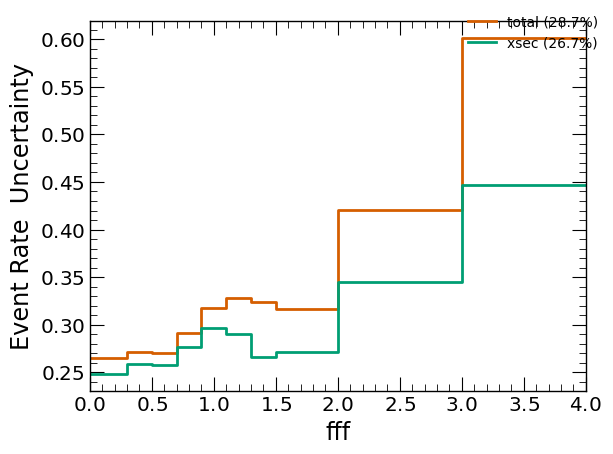

In [109]:
msystematics.xlabel = 'fff'
fig,ax,_ = msystematics.plot_event_rate_errs('event',sort=True,include_keys=['total','xsec'])

In [104]:
ax.legend(ncol=1,loc='upper right',bbox_to_anchor=(1.05, 1.05))
plt.show()

In [193]:
FNAME = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v6/mc_smallpand_fullsyst_cut_norecomb.df'
key = 'evt_pand_signal_0'
slc = CAFSlice.load(FNAME,key=key)

In [189]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_truth_negativecnt.txt','w') as f:
  for col in slc.data.truth.keys():
    ssum = (slc.data.truth.loc[:,col] < 0).sum()
    string = f'{col}: {ssum}\n'
    if ssum > 0:
      f.write(string)

In [194]:
slc.data.truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ms3.idxmin()

(85, 166, 1)

In [196]:
ind = (85,166,1)
keys = ['run','subrun','evt',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ps3',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ps2',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ps1',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ms3',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ms2',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ms1',
  ]
cols = slc.get_key(keys)
slc.data.loc[ind,cols]

run                                                                             2783.0
subrun                                                                             4.0
evt                                                                               29.0
truth   CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4  ps3                 100.0
                                                             ps2                 100.0
                                                             ps1                 100.0
                                                             ms3                  -inf
                                                             ms2                  -inf
                                                             ms1                  -inf
Name: (85, 166, 1), dtype: float64

In [81]:
slc.data.keys()

Index(['pot', 'first_in_subrun', 'ismc', 'run', 'subrun', 'ngenevt', 'evt',
       'proc', 'cluster', 'fno', 'noffbeambnb'],
      dtype='object')

In [66]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_weights2.txt','w') as f:
  for k in df.keys():
    f.write(f'{k}\n')


In [190]:
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v4/mc_singlepand_slimsyst_nocuts_norecomb2.df'
h5 = h5py.File(fname,'r')
h5.keys()

<KeysViewHDF5 ['evt_pand_0', 'hdr_0', 'histgenevtdf_0', 'histpotdf_0', 'mcnu_0', 'split']>

In [ ]:
df = pd.read_hdf(fname,key='evt_pand_0')

In [ ]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_slimsyst_keys.txt','w') as f:
  for k in df.truth.keys():
    f.write(f'{k}\n')

In [63]:
import uproot
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v6/single.root'
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tmp/temp0_ec6a979a-7730-4e0d-bcb2-82fbbb5ac2ae.flat.caf.root'
#fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbn/data_add/sbn_nd/poms_production/mc/MCP2025B_v10_06_00_09/v10_06_00_09/prodgenie_corsika_proton_rockbox_sbnd/CV/caf/00/00/caf-340768b0-4bb8-4575-8a9a-c64e68efc880.root'
fname = '/exp/sbnd/app/users/gputnam/Ar23-knobs/test.root'
tree = uproot.open(fname)['recTree']#['rec/slc']
tree.keys()
[k for k in tree.keys() if 'barycenterFM' in k]

['rec.slc.barycenterFM.chargeCenter.x',
 'rec.slc.barycenterFM.chargeCenter.y',
 'rec.slc.barycenterFM.chargeCenter.z',
 'rec.slc.barycenterFM.chargeCenterXLocal',
 'rec.slc.barycenterFM.chargeTotal',
 'rec.slc.barycenterFM.chargeWidth.x',
 'rec.slc.barycenterFM.chargeWidth.y',
 'rec.slc.barycenterFM.chargeWidth.z',
 'rec.slc.barycenterFM.chi2',
 'rec.slc.barycenterFM.deltaT',
 'rec.slc.barycenterFM.deltaY',
 'rec.slc.barycenterFM.deltaY_Trigger',
 'rec.slc.barycenterFM.deltaZ',
 'rec.slc.barycenterFM.deltaZ_Trigger',
 'rec.slc.barycenterFM.flashAsymmetry',
 'rec.slc.barycenterFM.flashCenter.x',
 'rec.slc.barycenterFM.flashCenter.y',
 'rec.slc.barycenterFM.flashCenter.z',
 'rec.slc.barycenterFM.flashFirstHit',
 'rec.slc.barycenterFM.flashPEs',
 'rec.slc.barycenterFM.flashTime',
 'rec.slc.barycenterFM.flashWidth.x',
 'rec.slc.barycenterFM.flashWidth.y',
 'rec.slc.barycenterFM.flashWidth.z',
 'rec.slc.barycenterFM.overlapY',
 'rec.slc.barycenterFM.overlapZ',
 'rec.slc.barycenterFM.radius

In [58]:
tree['globalTree/global/wgts/wgts.name'].arrays(library='np')

{'wgts.name': array([array(['GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE',
               'GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE',
               'GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE',
               'GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE',
               'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape',
               'GENIEReWeight_SBN_v1_multisigma_RPA_CCQE',
               'GENIEReWeight_SBN_v1_multisigma_CoulombCCQE',
               'GENIEReWeight_SBN_v1_multisigma_NormCCMEC',
               'GENIEReWeight_SBN_v1_multisigma_NormNCMEC',
               'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC',
               'GENIEReWeight_SBN_v1_multisigma_MaNCEL',
               'GENIEReWeight_SBN_v1_multisigma_EtaNCEL',
               'GENIEReWeight_SBN_v1_multisigma_MaCCRES',
               'GENIEReWeight_SBN_v1_multisigma_MvCCRES',
               'GENIEReWeight_SBN_v1_multisigma_MaNCRES',
               'GENIEReWeight_SBN_v1_multisigma_MvNCRES',
               'GENIEReWeigh

In [522]:
import uproot
bugfix_fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbnd/persistent/users/apapadop/GENIETweakedSamples/v3_6_2_AR23_20i_00_000_liang_bugfix/14_1000180400_CC_v3_6_2_AR23_20i_00_000.flat.root'
tree = uproot.open(bugfix_fname)
df_bf = tree['FlatTree_VARS'].arrays(library='pd')

nominal_fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbnd/persistent/users/apapadop/GENIETweakedSamples/v3_6_2_AR23_20i_00_000/14_1000180400_CC_v3_6_2_AR23_20i_00_000.flat.root'
tree = uproot.open(nominal_fname)
df_nom = tree['FlatTree_VARS'].arrays(library='pd')

In [536]:
df_nom.keys()

Index(['Mode', 'GENIEResCode', 'cc', 'PDGnu', 'Enu_true', 'tgt', 'tgta',
       'tgtz', 'PDGLep', 'ELep', 'CosLep', 'Q2', 'q0', 'q3', 'Enu_QE', 'Q2_QE',
       'W_nuc_rest', 'W', 'W_genie', 'x', 'y', 'Erecoil_minerva',
       'Erecoil_charged', 'EavAlt', 'Emiss', 'pmiss', 'Emiss_preFSI',
       'pmiss_preFSI', 'CosThetaAdler', 'PhiAdler', 'dalphat', 'dpt', 'dphit',
       'pnreco_C', 'nfsp', 'px', 'py', 'pz', 'E', 'pdg', 'pdg_rank', 'ninitp',
       'px_init', 'py_init', 'pz_init', 'E_init', 'pdg_init', 'nvertp',
       'px_vert', 'py_vert', 'pz_vert', 'E_vert', 'pdg_vert', 'Weight',
       'InputWeight', 'RWWeight', 'fScaleFactor', 'CustomWeight',
       'CustomWeightArray', 'flagCCINC', 'flagNCINC', 'flagCCQE', 'flagCC0pi',
       'flagCCQELike', 'flagNCEL', 'flagNC0pi', 'flagCCcoh', 'flagNCcoh',
       'flagCC1pip', 'flagNC1pip', 'flagCC1pim', 'flagNC1pim', 'flagCC1pi0',
       'flagNC1pi0', 'flagCC0piMINERvA', 'flagCC0Pi_T2K_AnaI',
       'flagCC0Pi_T2K_AnaII'],
      dtype='object

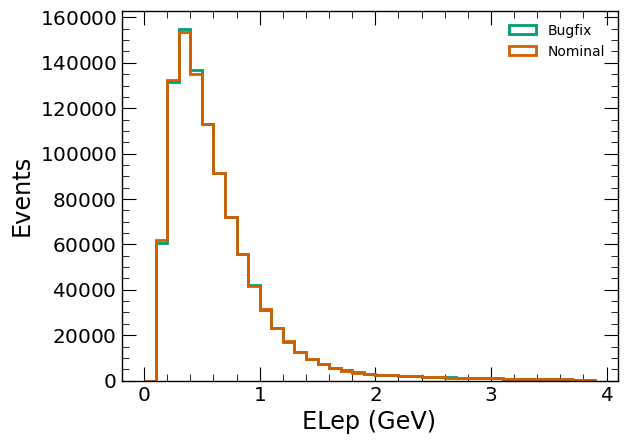

In [ ]:
#np.arange(0,4,.1)
plt.hist([df_nom['ELep'],df_bf['ELep']],bins=np.arange(0,4,.1),label=['Nominal','Bugfix'],histtype='step');
plt.legend();
plt.xlabel('ELep (GeV)');
plt.ylabel('Events');

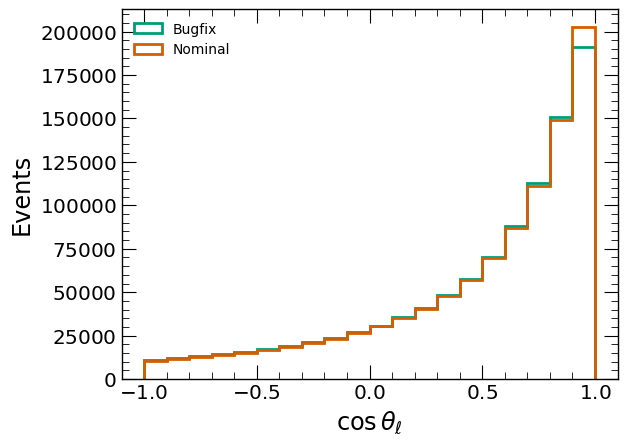

In [541]:
plt.hist([df_nom['CosLep'],df_bf['CosLep']],bins=np.arange(-1,1.1,.1),label=['Nominal','Bugfix'],histtype='step');
plt.legend();
plt.xlabel(r'$\cos\theta_\ell$');
plt.ylabel('Events');

In [812]:
from analysis_village.unfolding.wienersvd import WienerSVD

print("=== Test 1: Perfect Case ===")
n_bins = 5
identity_response = np.eye(n_bins)
identity_response[1,0] = 0.1
test_signal = np.array([100.0, 100.0, 100.0, 100.0, 100.0])
test_measured = test_signal.copy()  # Same as signal
test_measured[1] = 1000.0
test_cov = np.diag(test_signal)*100  # Identity covariance

result1 = WienerSVD(identity_response, test_signal, test_measured, test_cov, 0, 0.0)
print(f"Unfolded result: {result1['unfold']}")
print(f"Should equal signal: {np.allclose(result1['unfold'], test_signal)}")
print(f"AddSmear should be identity: {np.allclose(result1['AddSmear'], np.eye(n_bins))}")
print("AddSmear matrix:")
print(result1['AddSmear'])
print(f"AddSmear diagonal: {np.diag(result1['AddSmear'])}")
print(f"AddSmear column sums: {np.sum(result1['AddSmear'], axis=0)}")

=== Test 1: Perfect Case ===
-Response: [[1.  0.  0.  0.  0. ]
 [0.1 1.  0.  0.  0. ]
 [0.  0.  1.  0.  0. ]
 [0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1. ]]
-Signal: [100. 100. 100. 100. 100.]
-Measure: [ 100. 1000.  100.  100.  100.]
-Covariance: [[10000.     0.     0.     0.     0.]
 [    0. 10000.     0.     0.     0.]
 [    0.     0. 10000.     0.     0.]
 [    0.     0.     0. 10000.     0.]
 [    0.     0.     0.     0. 10000.]]
-C_type: 0
-Norm_type: 0.0
-U_cov: [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
-s_cov: [10000. 10000. 10000. 10000. 10000.]
-Q0: [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
-Q: [[0.01 0.   0.   0.   0.  ]
 [0.   0.01 0.   0.   0.  ]
 [0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]
 [0.   0.   0.   0.   0.01]]
-M_trans: [ 1. 10.  1.  1.  1.]
-R: [[0.01  0.    0.    0.    0.   ]
 [0.001 0.01  0.    0.    0.   ]
 [0.    0.    0.01  0.    0.   ]
 [0.    0.    0

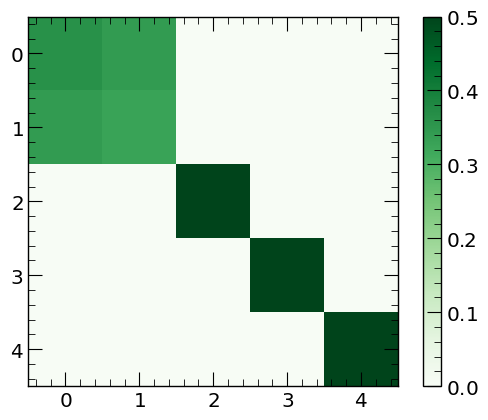

In [813]:
plt.imshow(result1['AddSmear'])
plt.colorbar()

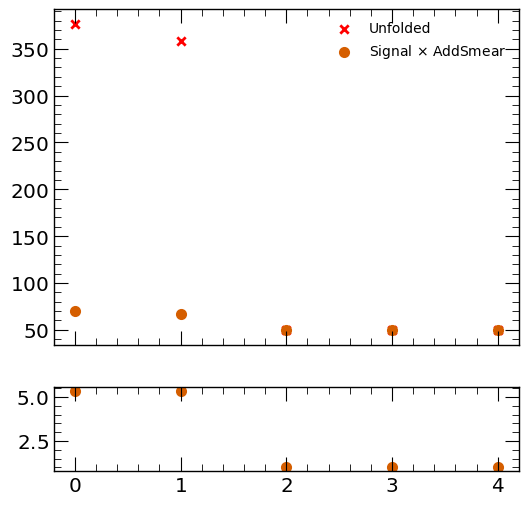

In [814]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(6,6),sharex=True,height_ratios=[4,1])
ax1.scatter(np.arange(n_bins),result1['unfold'],marker='x',color='red',label='Unfolded')
ax1.scatter(np.arange(n_bins),test_signal@result1['AddSmear'],label=r'Signal $\times$ AddSmear')
ax2.scatter(np.arange(n_bins),result1['unfold']/(test_signal@result1['AddSmear']))
ax1.legend()


In [808]:
_inter = inter.copy()

In [282]:
flux_keys = list(set([k[1] for k in _inter.data.keys() if 'Flux' in k[1]]))
with open('flux_keys.txt','w') as f:
  f.write(str(flux_keys))
flux_keys


['pionqexsec_Flux',
 'kplus_Flux',
 'pioninexsec_Flux',
 'nucleontotxsec_Flux',
 'nucleoninexsec_Flux',
 'horncurrent_Flux',
 'piplus_Flux',
 'piontotxsec_Flux',
 'kminus_Flux',
 'expskin_Flux',
 'nucleonqexsec_Flux',
 'Flux',
 'piminus_Flux',
 'kzero_Flux']

In [271]:
genie_keys = list(set([k[1] for k in slc.data.keys() if 'GENIE' in k[1]]))
genie_keys

['GENIEReWeight_SBN_v1_multisigma_NormNCMEC',
 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvnCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_RDecBR1eta',
 'GENIE',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarpCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvnCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpNC2pi',
 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarnNC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NormCCCOH',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpNC1pi',
 'GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_RDecBR1gamma',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarpCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape',
 'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarnNC2pi',
 'GENIEReWeight_SBN_v

In [83]:
_inter.add_stat_unc()

Generating event seeds: 100%|██████████| 309285/309285 [00:02<00:00, 110934.58it/s]


Successfully generated 309285 unique seeds


Generating universes: 100%|██████████| 100/100 [01:41<00:00,  1.02s/it]


In [86]:
_inter.data.truth.stat.univ_0.value_counts(normalize=True)

univ_0
1.0    0.367936
0.0    0.367386
2.0    0.184655
3.0    0.061238
4.0    0.015167
5.0    0.002971
6.0    0.000566
7.0    0.000061
8.0    0.000019
Name: proportion, dtype: float64

In [160]:
fname = f'{os.path.join(DATA_DIR,"small/mc_small_syst_postprocess_cut.df")}'
#df = pd.read_hdf(fname,key='evt_0')

In [38]:
list(df.keys())

[('id', '', '', '', '', ''),
 ('is_cathode_crosser_x', '', '', '', '', ''),
 ('is_contained_x', '', '', '', '', ''),
 ('is_fiducial_x', '', '', '', '', ''),
 ('is_flash_matched', '', '', '', '', ''),
 ('is_truth', '', '', '', '', ''),
 ('num_particles_x', '', '', '', '', ''),
 ('num_primary_particles_x', '', '', '', '', ''),
 ('vertex', 'x', '', '', '', ''),
 ('vertex', 'y', '', '', '', ''),
 ('vertex', 'z', '', '', '', ''),
 ('flash_hypo_pe', '', '', '', '', ''),
 ('flash_total_pe', '', '', '', '', ''),
 ('match_overlaps', '', '', '', '', ''),
 ('current_type', '', '', '', '', ''),
 ('energy_init', '', '', '', '', ''),
 ('energy_transfer', '', '', '', '', ''),
 ('num_particles_y', '', '', '', '', ''),
 ('num_primary_particles_y', '', '', '', '', ''),
 ('inelasticity', '', '', '', '', ''),
 ('interaction_mode', '', '', '', '', ''),
 ('interaction_type', '', '', '', '', ''),
 ('is_cathode_crosser_y', '', '', '', '', ''),
 ('is_contained_y', '', '', '', '', ''),
 ('is_fiducial_y', '', ''

In [161]:
with h5py.File(fname, 'r') as f:
    keys = list(f.keys())  # Convert the KeysViewWithLock object to a list for easier viewing
    print(keys)

['mcnu', 'pandora', 'pandora_signal', 'spine', 'spine_signal']
